<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula02a_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [2]:
X = data.data
print(X.shape)

(442, 10)


In [3]:
y = data.target
print(y.shape)

(442,)


2


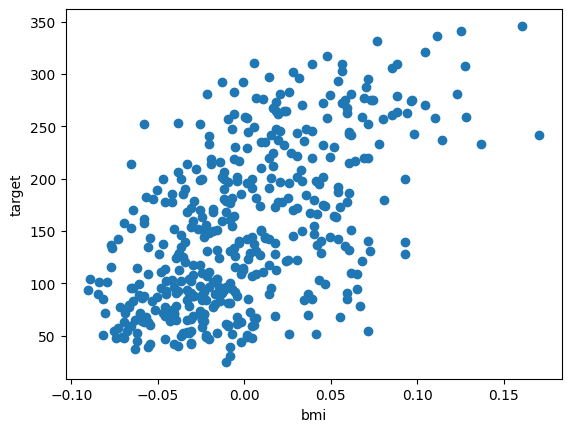

In [4]:
import matplotlib.pyplot as plt
for i in [2]: #range(X.shape[1]):
    print(i)
    plt.scatter(X[:,i],y)
    plt.xlabel(data.feature_names[i])
    plt.ylabel("target")
    plt.show()

In [5]:
import numpy as np

def train_test_split(X, y, test_size=0.2, random_state=42):
  np.random.seed(random_state)
  idx = np.random.permutation(len(X))
  X = X[idx]
  y = y[idx]
  split_idx = int(len(X)*(1-test_size))
  X_train, X_test = X[:split_idx], X[split_idx:]
  y_train, y_test = y[:split_idx], y[split_idx:]
  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(353, 10) (89, 10) (353,) (89,)


In [6]:
X2 = X_train[:,2:3]
print(X2.shape)

(353, 1)


In [7]:
def modelo_linear(X, a, b):
  y = a*X + b
  return y

In [19]:
def plot_results(X, y, ypred):
  plt.scatter(X, y, alpha=0.3)
  plt.plot(X, ypred, 'r')
  plt.show()

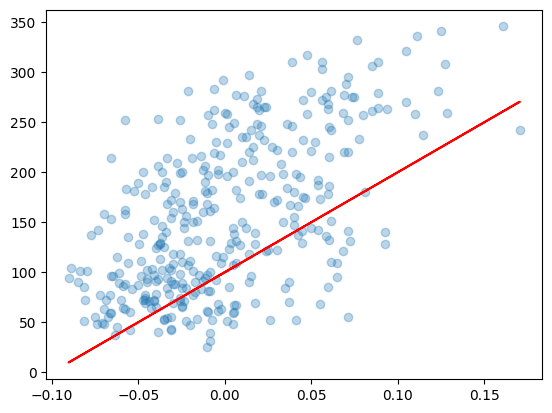

In [26]:
y_pred = modelo_linear(X2, 1000, 100)
plot_results(X2, y_train, y_pred)

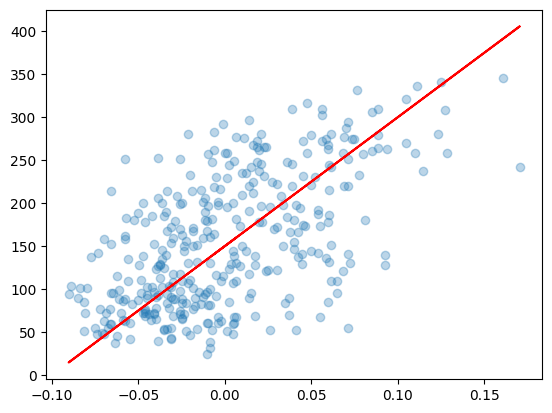

In [27]:
y_pred = modelo_linear(X2, 1500, 150)
plot_results(X2, y_train, y_pred)

In [28]:
# mean absolute error
def mae(y, y_pred):
  diff = y - y_pred.reshape(len(y), )
  abs_diff = abs(diff)
  sum_error = np.sum(abs_diff)
  mae = sum_error / len(y)
  return mae

mae(y_train, modelo_linear(X2, 1000, 100)), mae(y_train, modelo_linear(X2, 1500, 150))

(np.float64(67.15506392632298), np.float64(54.673882289467066))

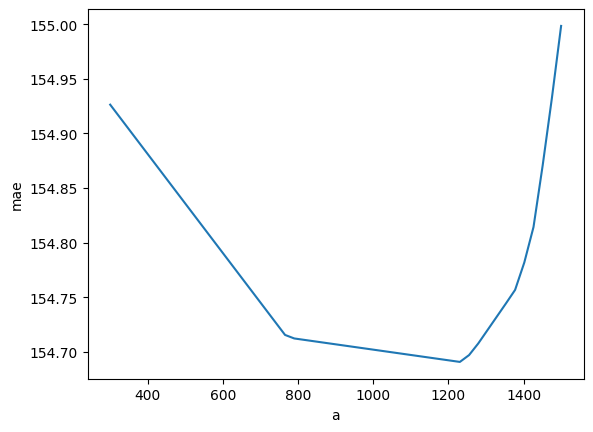

In [51]:
def plot_metric_by_a(X, y, metric, inference_function, min_a, max_a):
  a_values = np.linspace(min_a, max_a)
  y_preds = inference_function(X, a_values, 0)
  metric_values = [metric(y, y_pred) for y_pred in y_preds.T]
  plt.plot(a_values, metric_values)
  plt.xlabel("a")
  plt.ylabel(metric.__name__)

plot_metric_by_a(X2, y_train, mae, modelo_linear, 300, 1500)
plt.show()

In [54]:
# mean squared erorr
def mse(y, y_pred):
  diff = y - y_pred.reshape(len(y), )
  squared = diff**2
  mean = sum(squared)/len(squared)
  return mean

mse(y_train, modelo_linear(X2, 1000, 100)), mse(y_train, modelo_linear(X2, 1500, 150))

(np.float64(6893.019817492623), np.float64(4646.196968361406))

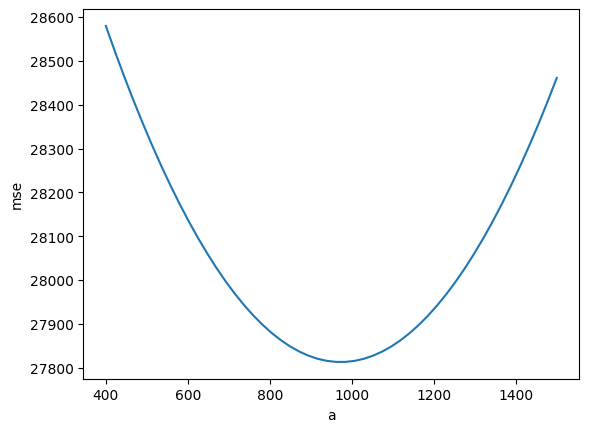

In [56]:
plot_metric_by_a(X2, y_train, mse, modelo_linear, 400, 1500)
plt.show()

In [58]:
# root mean squared error
def rmse(y, ypred):
  return np.sqrt(mse(y, ypred))

rmse(y_train, modelo_linear(X2, 1000, 100)), rmse(y_train, modelo_linear(X2, 1500, 150))

(np.float64(83.02421223650738), np.float64(68.16301760017235))

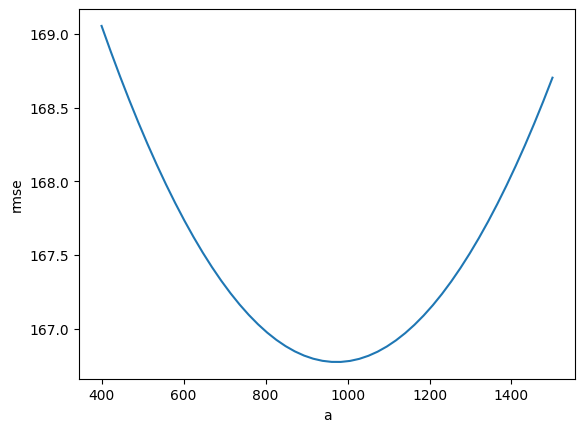

In [59]:
plot_metric_by_a(X2, y_train, rmse, modelo_linear, 400, 1500)
plt.show()

In [61]:
def modelo_media(y):
  media = np.mean(y)
  y_pred = np.ones_like(y)*media
  return y_pred

mse(y_train, modelo_linear(X2, 1500, 150)), mse(y_train, modelo_media(y_train))

(np.float64(4646.196968361406), np.float64(5978.5853509778635))

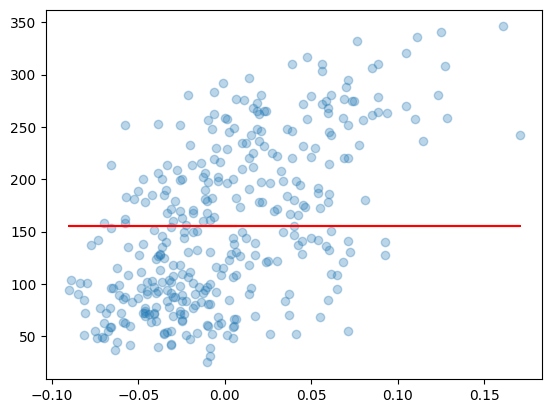

In [62]:
y_pred = modelo_media(y_train)
plot_results(X2, y_train, y_pred)

In [64]:
def r2_score(y, y_pred):
  ss_res = mse(y, y_pred)
  ss_tot = mse(y, modelo_media(y))
  r2 = 1 - (ss_res/ss_tot)
  return r2

r2_score(y_train, modelo_linear(X2, 1500, 150)), r2_score(y_train, modelo_media(y_train))

(np.float64(0.22286014239113117), np.float64(0.0))

5978.5853509778635


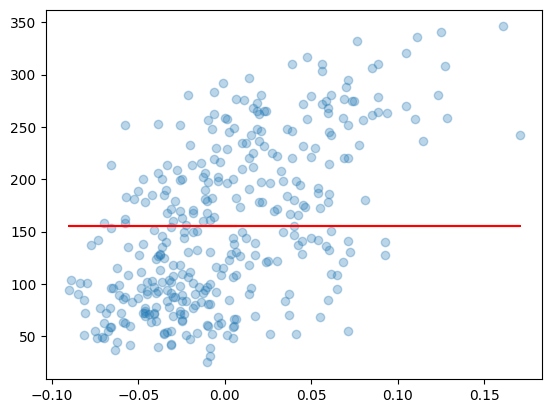

In [69]:
from sklearn.base import BaseEstimator, RegressorMixin

class AverageRegressor(BaseEstimator, RegressorMixin):
  def fit(self, X, y):
    self.media_ = np.mean(y)
    return
  def predict(self, X):
    y_pred = np.ones(shape=(X.shape[0],))*self.media_
    return y_pred

regressor = AverageRegressor()
regressor.fit(X2, y_train)
y_pred = regressor.predict(X2)
print(mse(y_train, y_pred))
plot_results(X2, y_train, y_pred)

4646.196968361406


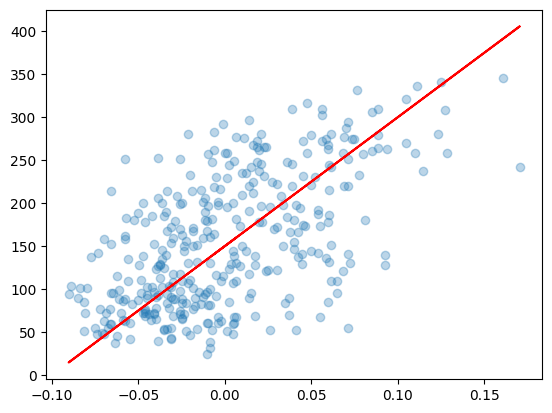

In [70]:
class LinearRegressor(BaseEstimator, RegressorMixin):
  def __init__(self, a, b):
    self.a_ = a
    self.b_ = b
  def fit(self, X, y):
    return self
  def predict(self, X):
    y_pred = self.a_*X + self.b_
    return y_pred.reshape(X.shape[0], )

regressor = LinearRegressor(1500, 150)
regressor.fit(X2, y_train)
y_pred = regressor.predict(X2)
print(mse(y_train, y_pred))
plot_results(X2, y_train, y_pred)

29993.300925346193


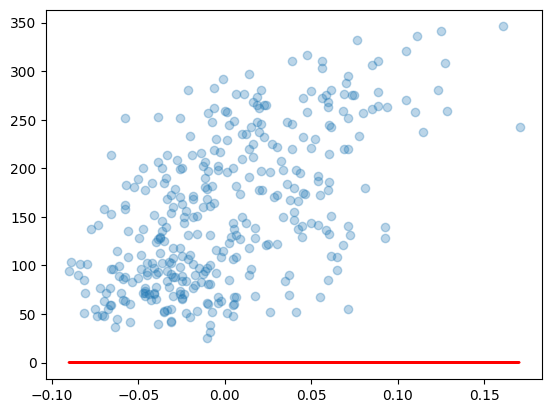

In [75]:
class LinearRegressor(BaseEstimator, RegressorMixin):
  def fit(self, X, y):
    self.a_ = np.random.rand()
    self.b_ = np.random.rand()
    return self
  def predict(self, X):
    y_pred = self.a_*X + self.b_
    return y_pred.reshape(X.shape[0], )

regressor = LinearRegressor()
regressor.fit(X2, y_train)
y_pred = regressor.predict(X2)
print(mse(y_train, y_pred))
plot_results(X2, y_train, y_pred)

[529.64525529] 154.8226859117432
4302.155780140378


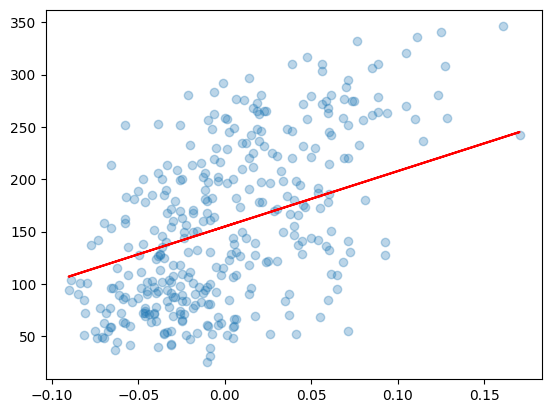

In [84]:
class LinearRegressor(BaseEstimator, RegressorMixin):
  def __init__(self, max_iter=1000, learning_rate=0.001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate

  def fit(self, X, y):
    self.coefs_ = np.random.rand(X.shape[1])
    self.intercept_ = np.random.rand()
    for i in range(self.max_iter):
      # print(self.coefs_)
      y_pred = self.predict(X)
      error = y - y_pred
      self.coefs_ += X.T @ error * self.learning_rate
      self.intercept_ += error.sum() * self.learning_rate
    return self

  def predict(self, X):
    y_pred = X @ self.coefs_ + self.intercept_
    return y_pred.reshape(X.shape[0], )

regressor = LinearRegressor()
regressor.fit(X2, y_train)
y_pred = regressor.predict(X2)
print(regressor.coefs_, regressor.intercept_)
print(mse(y_train, y_pred))
plot_results(X2, y_train, y_pred)

In [86]:
y_pred = modelo_linear(X2, 529.64525529, 154.8226859117432)
print(mse(y_train, y_pred))

4302.155780142628


[  50.1967364   -81.54179111  347.51391229  210.06232064    2.36330891
  -38.17753803 -195.97918082  153.12354213  317.11227036  152.26732812] 154.03669851528582
3027.1187178267332


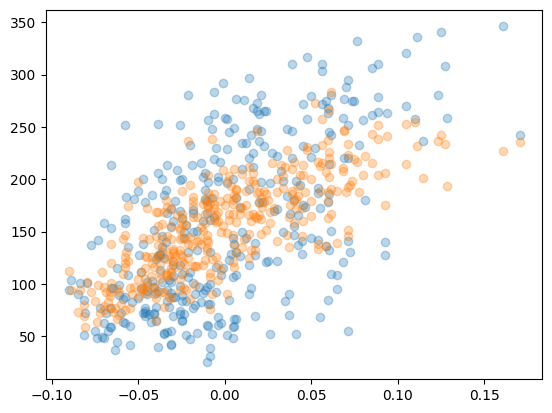

In [88]:
regressor = LinearRegressor()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_train)
print(regressor.coefs_, regressor.intercept_)
print(mse(y_train, y_pred))
plt.scatter(X2, y_train, alpha=0.3)
plt.scatter(X2, y_pred, alpha=0.3)
plt.show()